Treinamento de um modelo de regressão usando XGBoost

In [1]:
import pandas as pd
df = pd.read_csv('casas_california.csv')
df

,longitude,latitude,idade_mediana_imoveis,total_comodos,total_quartos,populacao,domicilios,renda_mediana,valor_mediano_imoveis,proximidade_oceano
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [2]:
#Transformação de variaveis não numericas em numericas
from sklearn.preprocessing import LabelEncoder


le = LabelEncoder()

df['proximidade_oceano'] = le.fit_transform(df['proximidade_oceano'])
df['proximidade_oceano'].value_counts()

proximidade_oceano
0    9136
1    6551
4    2658
3    2290
2       5
Name: count, dtype: int64

In [3]:
df.columns

Index(['longitude', 'latitude', 'idade_mediana_imoveis', 'total_comodos',
       'total_quartos', 'populacao', 'domicilios', 'renda_mediana',
       'valor_mediano_imoveis', 'proximidade_oceano'],
      dtype='object')

In [4]:
#Normalização dos dados
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
colunas_numericas = ['longitude', 'latitude', 'idade_mediana_imoveis', 'total_comodos',
       'total_quartos', 'populacao', 'domicilios', 'renda_mediana']

df[colunas_numericas] = scaler.fit_transform(df[colunas_numericas])
df

,longitude,latitude,idade_mediana_imoveis,total_comodos,total_quartos,populacao,domicilios,renda_mediana,valor_mediano_imoveis,proximidade_oceano
0,-1.327835,1.052548,0.982143,-0.804819,-0.970325,-0.974429,-0.977033,2.344766,452600.0,3
1,-1.322844,1.043185,-0.607019,2.045890,1.348276,0.861439,1.669961,2.332238,358500.0,3
2,-1.332827,1.038503,1.856182,-0.535746,-0.825561,-0.820777,-0.843637,1.782699,352100.0,3
3,-1.337818,1.038503,1.856182,-0.624215,-0.718768,-0.766028,-0.733781,0.932968,341300.0,3
4,-1.337818,1.038503,1.856182,-0.462404,-0.611974,-0.759847,-0.629157,-0.012881,342200.0,3
...,...,...,...,...,...,...,...,...,...,...
20635,-0.758826,1.801647,-0.289187,-0.444985,-0.388895,-0.512592,-0.443449,-1.216128,78100.0,1
20636,-0.818722,1.806329,-0.845393,-0.888704,-0.920488,-0.944405,-1.008420,-0.691593,77100.0,1
20637,-0.823713,1.778237,-0.924851,-0.174995,-0.125472,-0.369537,-0.174042,-1.142593,92300.0,1
20638,-0.873626,1.778237,-0.845393,-0.355600,-0.305834,-0.604429,-0.393753,-1.054583,84700.0,1


In [5]:
#Preparação dos dados de entrada e saida
x = df.drop('valor_mediano_imoveis', axis=1)
y = df['valor_mediano_imoveis']

In [6]:
from sklearn.model_selection import train_test_split

#Preparação dos Dados de treino e teste
xtreino, xteste, ytreino, yteste = train_test_split(x, y, test_size=0.3)

In [7]:
#Parâmetros do modelo
from xgboost import XGBRegressor

modelo_xgboost = XGBRegressor(n_estimators=500, max_depth = 6, leaning_rate = 0.1, random_state = 42)
modelo_xgboost.fit(xtreino, ytreino)

[20:52:42] WARNING: C:/Users/administrator/workspace/xgboost-win64_release_1.6.0/src/learner.cc:627: 
Parameters: { "leaning_rate" } might not be used.

  This could be a false alarm, with some parameters getting used by language bindings but
  then being mistakenly passed down to XGBoost core, or some parameter actually being used
  but getting flagged wrongly here. Please open an issue if you find any such cases.




,objective,'reg:squarederror'
,base_score,0.5
,booster,'gbtree'
,callbacks,None
,colsample_bylevel,1
,colsample_bynode,1
,colsample_bytree,1
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None
,gamma,0


In [8]:

from sklearn.metrics import r2_score, mean_absolute_percentage_error

#Avaliação do modelo (MAPE E R2)

#Previsão para os dados de treino e teste
ypred_treino = modelo_xgboost.predict(xtreino)
ypred_teste = modelo_xgboost.predict(xteste)

#Métricas

mape_treino = mean_absolute_percentage_error(ytreino, ypred_treino)
mape_teste = mean_absolute_percentage_error(yteste, ypred_teste)


r2_treino = r2_score(ytreino, ypred_treino)
r2_teste = r2_score(yteste, ypred_teste)


In [9]:
# Resultados para treino
print("Resultados - Treino")
print(f"MAPE: {mape_treino * 100}")
print(f"R2: {r2_treino}")


print("\nResultados - Teste")
print(f"MAPE: {mape_teste * 100}")
print(f"R2: {r2_teste}")

Resultados - Treino
MAPE: 4.182512327123968
R2: 0.9930975939033507

Resultados - Teste
MAPE: 17.574595819514734
R2: 0.8348892806621502


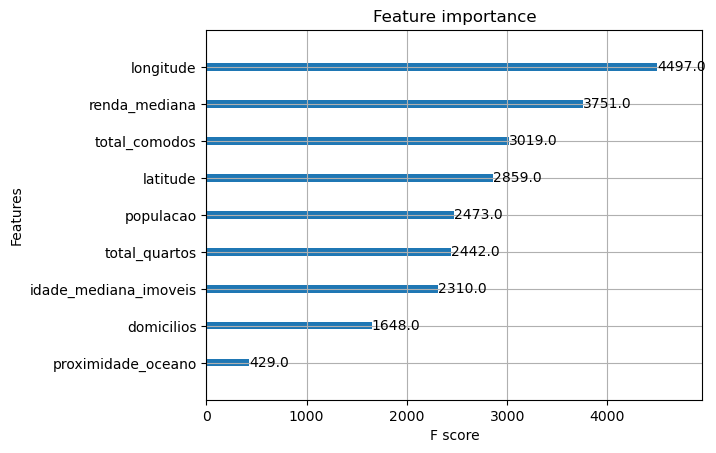

In [10]:
import  matplotlib.pyplot as plt
from xgboost import plot_importance

plot_importance(modelo_xgboost)
plt.show()